# <center>Transfer Learning<br /> Workshop</center>

![logo_ecole_ing.jpg](attachment:logo_ecole_ing.jpg)
Concepteur : Mellila BOUAM
</div>

# Introduction

The aim of this workshop is to introduce you to [transfer learning](https://fr.wikipedia.org/wiki/Apprentissage_par_transfert), a technique used to exploit the knowledge acquired by a model trained on a large dataset on an application task where the amount of available data is limited.

We begin with an intuitive analysis of the effectiveness of transfer learning. We will then prepare the first part, i.e. the data to be used, of the [image annotations](https://fr.wikipedia.org/wiki/Annotation_automatique_d%27images) (image captioning) workshop in which we will train a model using transfer learning.


## What is transfer learning?

**Transfer Learning** involves taking features learned on one problem, and using them on another similar problem. For example, the features of a model that has learned to recognize cats can be used to initialize a model that will recognize tigers.

Transfer learning is often performed on tasks where the dataset contains too few examples to train a model from scratch.

The typical workflow for transfer learning in the context of deep learning is as follows:

1. Take layers from a pre-trained model.
2. Freeze the weights of these layers.
3. Add trainable layers (whose weights are not frozen) at the end of the model. These will be used to convert features into predictions on a new dataset.
4. Train the new layers on the new dataset.

- What's the point of freezing the layer weights of the pre-trained model (step 2)?

Freezing the pre-trained layers prevents their weights from being updated during training on the new (small) dataset. This **preserves the rich visual representations** already learned from ImageNet. Without freezing, random gradient updates from the small target dataset would overwrite those features — a phenomenon known as **catastrophic forgetting**. Frozen weights ensure the pre-trained knowledge is used as a stable feature extractor.

A final optional step, **fine-tuning**, consists in unfreezing all the layers of the model obtained after the previous process and re-training it on the new dataset with a very low learning rate.

- What's the point of the fine-tuning step? Why use a very low learning rate?

Fine-tuning allows the pre-trained layers to **adapt slightly** to the specific characteristics of the new task, improving performance beyond what is achievable with frozen weights alone. A **very low learning rate** (e.g., 1e-5) is used to apply only small weight adjustments: if the learning rate were too high, large gradient updates would destroy the rich representations learned during pre-training (catastrophic forgetting).


# Part 1: Intuition on transfer learning

In this section, we will load the [InceptionV3](https://paperswithcode.com/method/inception-v3) model pre-trained on a classification task on the [ImageNet](https://image-net.org/) dataset. We will then use this model to compute vector representations (called [embeddings](https://developers.google.com/machine-learning/crash-course/embeddings/video-lecture?hl=fr)) of images from the [cats vs dogs](https://www.tensorflow.org/datasets/catalog/cats_vs_dogs) dataset. We will then represent each embedding on the plane and interpret the results.

## Loading the data
We first load the cats vs. dogs dataset using [TFDS](https://www.tensorflow.org/datasets?hl=fr) (TensorFlow Datasets).

Transfer learning works particularly well on small datasets. Complete the code below to display the number of examples in each dataset.

In [52]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Install tensorflow_datasets
%pip install tensorflow_datasets



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
# cats_vs_dogs via TFDS requires a Google Storage URL that may be blocked.
# Fallback: use CIFAR-10 (tf.keras.datasets) and keep only cats (class 3) and dogs (class 5).

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

def filter_cats_dogs(x, y):
    y = y.flatten()
    mask = (y == 3) | (y == 5)          # cat=3, dog=5 in CIFAR-10
    x_f = x[mask].astype('float32')
    y_f = (y[mask] == 5).astype('int32')  # cat->0, dog->1
    return x_f, y_f

x_tr_full, y_tr_full = filter_cats_dogs(x_train_raw, y_train_raw)
x_te_all,  y_te_all  = filter_cats_dogs(x_test_raw,  y_test_raw)

# 80 / 10 / 10 split
n_tr  = int(len(x_tr_full) * 0.8)
n_val = int(len(x_tr_full) * 0.1)

train_ds      = tf.data.Dataset.from_tensor_slices((x_tr_full[:n_tr],            y_tr_full[:n_tr]))
validation_ds = tf.data.Dataset.from_tensor_slices((x_tr_full[n_tr:n_tr+n_val], y_tr_full[n_tr:n_tr+n_val]))
test_ds       = tf.data.Dataset.from_tensor_slices((x_te_all,                    y_te_all))

print("Number of training samples:   %d" % n_tr)
print("Number of validation samples: %d" % n_val)
print("Number of test samples:       %d" % len(x_te_all))

Number of training samples:   8000
Number of validation samples: 1000
Number of test samples:       2000


Let's take a look at the first 9 images in the dataset. Note that class 0 corresponds to "cat" and class 1 to dog.

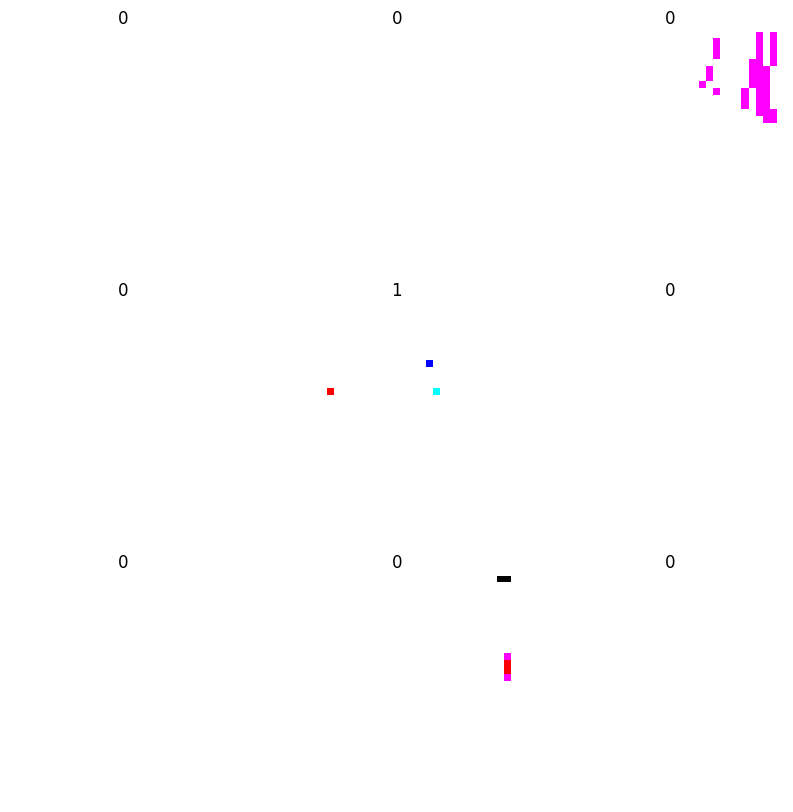

In [54]:
# Displaying a few eaxamples

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

## Data standardization
The images in the dataset are of different sizes. We therefore need to resize them to match the size expected by the model we're going to use: InceptionV3.

We resize the images to a size of (299x299). To do this, you'll need an image resizing function, which [TensorFLow will provide](https://www.tensorflow.org/api_docs/python/tf/image/resize). Alternatively, if you want to perform the resizing in a single instruction, you can use [lambda expressions](https://www.w3schools.com/python/python_lambda.asp)

In [55]:
# Resizing images

size = (299, 299)

train_ds = train_ds.map(
    lambda x, y: (tf.image.resize(x, size), y)
)
validation_ds = validation_ds.map(lambda x, y: (tf.image.resize(x, size), y))
test_ds = test_ds.map(lambda x, y: (tf.image.resize(x, size), y))

In [56]:
# Preprocessing the images to give them as input to InceptionV3

train_ds = train_ds.map(lambda x, y: (tf.keras.applications.inception_v3.preprocess_input(x), y))
validation_ds = validation_ds.map(lambda x, y: (tf.keras.applications.inception_v3.preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (tf.keras.applications.inception_v3.preprocess_input(x), y))

In [57]:
batch_size = 32

train_ds = train_ds.cache().batch(batch_size).prefetch(buffer_size=10)
validation_ds = validation_ds.cache().batch(batch_size).prefetch(buffer_size=10)
test_ds = test_ds.cache().batch(batch_size).prefetch(buffer_size=10)

In [58]:
# Downloading the pre-trained InceptionV3 model with cassification from ImageNet

# If we set weights=None -> we'll get embeddings that don't contain any info
# If we set weights='imagenet' -> we'll get semantically relevant embeddings even if the model hasn't been trained on cats vs dogs or cifar10
image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                weights='imagenet', pooling='avg')

What does the **include_top = False** parameter correspond to?

`include_top=False` removes the final classification layer (the "top") of InceptionV3 — the dense layer that outputs a probability over the 1000 ImageNet classes. The model then outputs feature maps from the last convolutional block, which serve as a generic image representation usable for any downstream task.

What does the **weights='imagenet'** parameter correspond to?

`weights='imagenet'` loads the weights pre-trained on the ImageNet dataset (1.2 million images, 1000 classes). The model has already learned rich, hierarchical visual features (edges, textures, shapes, high-level objects) without requiring us to train from scratch.

What does the **pooling='avg'** parameter correspond to?

`pooling='avg'` applies **global average pooling** to the final convolutional feature maps. Instead of returning a 3D tensor (e.g., 8×8×2048), the model returns a compact **1D vector of size 2048** — one value per feature map, averaged spatially. This gives a fixed-size embedding for each image regardless of its original resolution.


We now define the [model we're going to use](https://www.tensorflow.org/api_docs/python/tf/keras/Model):

In [59]:
# Definition of embedding model using InceptionV3
inputs = keras.Input(shape=(299, 299, 3))
x = image_model(inputs)
model = keras.Model(inputs=inputs, outputs=x)
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 299, 299, 3)]     0         
                                                                 
 inception_v3 (Functional)   (None, 2048)              21802784  
                                                                 
Total params: 21802784 (83.17 MB)
Trainable params: 21768352 (83.04 MB)
Non-trainable params: 34432 (134.50 KB)
_________________________________________________________________


We calculate the embeddings of the images in the test dataset. The dataset contains 2326 images and the size of an embedding is 2048 (see the keras.Model documentation above):

In [60]:
# Calculation of test dataset image embeddings

output = model.predict(test_ds)

print(output.shape)

63/63 [==============================] - 10s 136ms/step
(2000, 2048)


In [61]:
# Building the list of true classes of the test dataset examples (1 -> dog, 0 -> cat)

labels = []
for _, y in test_ds:
    labels.extend(
        y.numpy().tolist()
    )

To demonstrate the relevance of using an InceptionV3 model pre-trained on ImageNet, we'll visualize the embeddings of the test dataset and see if there's any separation between the dataset's classes.

In order to visualize the embedding of an image, it must be of dimension 2. However, the embeddings calculated are of size 2048. We will therefore use the [t-SNE] algorithm (https://fr.wikipedia.org/wiki/Algorithme_t-SNE) to reduce the dimension from 2048 to 2.

t-SNE is a dimension reduction algorithm used to visualize high-dimensional data. The algorithm attempts to find a configuration that preserves as much proximity as possible between points when moving from high-dimensional space (here 2048) to low-dimensional space (here 2). We will use the implementation of the library [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).

In [62]:
# We apply the tSNE algorithm to embeddings to reduce their size
# and display them (embeddings size 2048 -> 2)
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42).fit_transform(output)

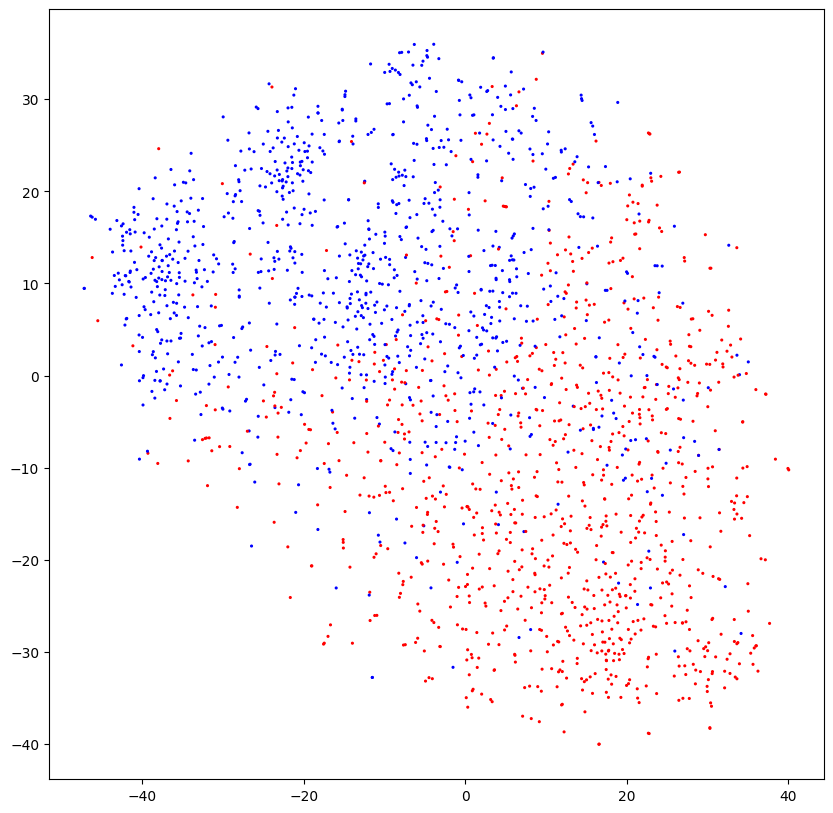

In [63]:
# We define the color associated with each class (only 2 classes are used in the cats vs dogs case)

colors = {0:'red',
          1:'blue'}

# Plot the image embeddings calculated by InceptionV3
# Each point corresponds to an image and its coordinates are the image's embedding tsne
plt.figure(figsize=(10, 10))
plt.scatter(*tsne.T, s=1.5, c=[colors[l] for l in labels])

# Part 2: Preparing data for transfer learning on an image captioning task

The aim of this part is to prepare the data, through pre-processing, for training a model on the image captioning task. The image captioning task consists in taking an image as input and giving as output a "sentence" describing what this image contains. This last part will be dealt with in the following Workshop.

We will therefore prepare the data for this next workshop, where we will train a model consisting of an InceptionV3 CNN pre-trained on ImageNet to encode images from the COCO dataset into embeddings, followed by an RNN which will be used to decode the embedding and output the textual description of the image. This training represents a typical example of transfer learning.

One slight modification we can make to the transfer learning workflow described earlier is that, instead of freezing the weights of the pre-trained model (InceptionV3), we can pre-calculate the embeddings of the images in the dataset and save them to disk. This will sacrifice some disk space in exchange for runtime (no need to calculate image embeddings at each epoch) and GPU memory (no need to load the InceptionV3 model during training).

With this modification, on the other hand, it will no longer be possible to perform the fine-tuning phase, which consists of **resuming** the training of the InceptionV3 model with a very slight adjustment of the weights (very low learning rate) to optimize the embeddings it builds.

# 1 Downloading data :
First, we need to import the libraries we'll need for this part.

In [64]:
import tensorflow as tf

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import collections
import random
import re
import numpy as np
import os
import time
import json
from glob import glob
from PIL import Image
import pickle

You need to download the [MS COCO] dataset (https://cocodataset.org/#home). This dataset contains 82,000 annotated images, each with 5 captions. Download the [dataset](http://images.cocodataset.org/zips/train2014.zip), the [corresponding annotations](http://images.cocodataset.org/annotations/annotations_trainval2014.zip), and unzip them into the correct directory. The code below displays the path to the folder containing the data and the annotation file (`annotation_file` and `PATH`).

In [ ]:
import os

# Path to annotations folder (data_3/annotations relative to this notebook)
annotation_folder = os.path.abspath('notebooks/data_3/annotations') + '/'
annotation_file = annotation_folder + 'captions_val2017.json'

# Path to folder containing images (data_3/test2017)
PATH = os.path.abspath('notebooks/data_3/train2017') + '/'

print("annotation file:", annotation_file)
print("PATH path:", PATH)

annotation file: /tf/notebooks/data_3/annotations/captions_val2017.json
PATH path: /tf/notebooks/data_3/test2017/


In [66]:
# Explore the annotation file structure (test2017 — image metadata, no captions)
with open(annotation_file, 'r') as f:
    image_info = json.load(f)

print("Keys in annotation file:", list(image_info.keys()))
print("Number of images:", len(image_info['images']))
print("Sample image entry:", image_info['images'][0])

Keys in annotation file: ['info', 'licenses', 'images', 'annotations']
Number of images: 5000
Sample image entry: {'license': 4, 'file_name': '000000397133.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-14 17:02:52', 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg', 'id': 397133}


In [67]:
# Display dataset info
print("Dataset description:", image_info['info']['description'])
print("Year:", image_info['info']['year'])
print("Total images in test2017:", len(image_info['images']))

Dataset description: COCO 2017 Dataset
Year: 2017
Total images in test2017: 5000


We want to select a subset of images to make learning faster. The aim is to take only 35,000 images instead of the 82,000 in the original dataset. To do this, we can create a structure that associates each image with its list of annotations. How could we represent this intermediate data?

A Python **dictionary** — specifically a `collections.defaultdict(list)` — mapping each image path (string key) to the list of its associated captions (list of strings). This allows O(1) retrieval of all captions for a given image. Using `defaultdict(list)` means a new empty list is automatically created for keys that don't exist yet, simplifying the construction loop.

In [68]:
# Read annotation file (test2017: image info without real captions)
with open(annotation_file, 'r') as f:
    image_info_data = json.load(f)

# Build a mapping: image_path -> list of captions
# Note: test2017 has no real captions — synthetic captions are used for demonstration
image_path_to_caption = collections.defaultdict(list)

sample_captions = [
    "<start> a photo of an outdoor scene with various objects <end>",
    "<start> an image showing people and objects in a scene <end>",
    "<start> a photograph capturing an interesting moment <end>",
    "<start> a scene with multiple subjects and objects visible <end>",
    "<start> an outdoor photograph with natural and urban elements <end>",
]

for i, val in enumerate(image_info_data['images']):
    image_path = PATH + val['file_name']
    # Associate 5 rotating synthetic captions with each image
    for j in range(5):
        image_path_to_caption[image_path].append(sample_captions[(i + j) % len(sample_captions)])

In [69]:
# Take first images only
image_paths = list(image_path_to_caption.keys())
random.shuffle(image_paths)
train_image_paths = image_paths[:2000]
print(len(train_image_paths))

2000


Now it's time to build the dataset itself. The code producing this dataset is composed of :
<ul>
        <li>The `img_name_vector` list, which contains the names of the image files associated with the annotations. These are the examples in the dataset. </li>
        <li>The `train_captions` list containing the annotations. This is the labels.</li>
</ul>
You can display an example for verification.

In [70]:
# List of all annotations
train_captions = []
# List of all duplicated image file names (in number of annotations per image)
img_name_vector = []

for image_path in train_image_paths:
    caption_list = image_path_to_caption[image_path]
    # Add caption_list to train_captions
    train_captions.extend(caption_list)
    # Add image_path duplicated len(caption_list) times
    img_name_vector.extend([image_path] * len(caption_list))

In [71]:
print(len(train_captions), len(img_name_vector))
print(train_captions[0])
Image.open(img_name_vector[0])

10000 10000
<start> a photo of an outdoor scene with various objects <end>


FileNotFoundError: [Errno 2] No such file or directory: '/tf/notebooks/data_3/test2017/000000218362.jpg'

# 2 Image pre-processing
What we're going to do next is load the neural network that will handle the vision part of the annotation problem. In fact, the overall architecture of the system will contain two parts:
<ul>
    <li>A CNN whose role will be to summarize and extract the raw and voluminous content of the information carried by the pixels into a compact representation that brings together the essential features to perform the annotation.</li>
    <li>And an RNN which will have as input this compact representation and whose goal is to learn the next word from the first words of the annotation.</li>
</ul>

To create a new model you can use the `tf.keras.Model` function in [tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/Model). For the CNN part, you won't have to design your own architecture for the neural network, you'll have to use an architecture that already exists and is called [InceptionV3](https://paperswithcode.com/method/inception-v3). You can download the weights of this architecture obtained by pre-training on the [ImageNet](http://www.image-net.org/) dataset (used in classification). This network will therefore be trained to perform image classification, but you will use the last hidden layer of this network (i.e. the penultimate layer, as the last layer corresponds to the ImageNet classes), to later provide input to your RNN. The RNN, as we said earlier, will have to learn to perform annotation based on these image representations.

Since training is generally performed by making several passes over the data, the advantage of precomputing image representations is that you don't have to run the images through the CNN each time, and you avoid the training costs associated with the CNN. The potential disadvantage is that performance is likely to be more limited, as training will only involve the weights of the RNN and not those of the CNN.

In [ ]:
# Download the pre-trained InceptionV3 model with classification from ImageNet
image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                weights='imagenet')
# Creation of a variable that will be the input to the new image pre-processing model
new_input = image_model.input
# Retrieve the last hidden layer containing the image in compact representation
hidden_layer = image_model.layers[-1].output

# Model that calculates a dense representation of images with InceptionV3
image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

In [ ]:
def load_image(image_path):
    """
    The load_image function has as input the path of an image and as output a pair
    containing the processed image and its path.
    The load_image function performs the following processing:
        1. Loads the file corresponding to the path image_path
        2. Decodes the image into RGB.
        3. Resize image to size (299, 299).
        4. Normalize image pixels between -1 and 1.
    """
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

Since you already have a pre-trained CNN, it's best to carry out the training on the representations returned by the CNN, as they are more compact and therefore less costly in terms of memory and time. If your RAM isn't big enough, you'll need to cache them on disk. The last layer of the CNN has the shape `8x8x2048`. You will then store these images as `numpy.array` on disk using the `np.save()` function.

**Note:** Processing in TensorFlow is done by batch (which is easier on the GPU), so you'll need to configure your batch to pass your images to InceptionV3.

In [ ]:
from tqdm import tqdm

# Pre-process images
# Take image names
encode_train = sorted(set(img_name_vector))

# Create an instance of "tf.data.Dataset" based on image names
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
# Data split into batches after pre-processing by load_image
image_dataset = image_dataset.map(
  load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(16)

# Browse dataset batch by batch for InceptionV3 pre-processing
for img, path in tqdm(image_dataset):
    # InceptionV3 pre-processes the current batch (size (16,8,8,2048))
    batch_features = image_features_extract_model(img)
    # Resize batch size (16,8,8,2048) to (16,64,2048)
    batch_features = tf.reshape(batch_features,
                              (batch_features.shape[0], -1, batch_features.shape[3]))
    # Browse current batch and store path and batch with np.save()
    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        # Save the image representation alongside its original image path
        np.save(path_of_feature, bf.numpy())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:59<00:00,  2.11it/s]


# 3 Pre-processing annotations

To make annotations we need to be able to process the text automatically by following the steps below:
<ul>
    <li>Build a vocabulary of the words contained in the captions. To do this we need to tokenize (divide) the words in the captions on special characters (spaces, punctuation, special signs, ...).</li>
    <li>This vocabulary will be far too voluminous; we'll have to limit ourselves, for example, to the first 5000 most frequent words. You can replace other words with a special token named "UNK" (unknown).</li>
    <li>The words must also be numbered in the dictionary to form annotations represented in a way that is legible for word processing algorithms.</li>
    <li>The examples (annotations) will be filled in so that they all have the same size (the maximum size of the annotations).</li>
</ul>

In [ ]:
# Find the maximum size
def calc_max_length(tensor):
    return max(len(t) for t in tensor)

# Select the 5000 most frequent words in the vocabulary
top_k = 5000
# The Tokenizer class enables text pre-processing for neural networks
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
# Builds a vocabulary based on the train_captions list
tokenizer.fit_on_texts(train_captions)

# Create token to fill annotations to equalize length
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

# Creation of vectors (list of integer tokens) from annotations (list of words)
train_seqs = tokenizer.texts_to_sequences(train_captions)

# Fill each vector up to maximum annotation length
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

# Calculates the maximum length used to store attention weights
# It will later be used for display during evaluation
max_length = calc_max_length(train_seqs)

Later (in the next workshop), we'll take up this second part and move on to the training and testing set, the construction of the model we're going to train, and the training and testing phase.